# Portfolio VaR & ES — Notebook 01: Data Pipeline

**Course:** Quantitative Financial Risk Management — Charles Bos, 2026/3
**Group:** Your Group Name

---

## Notebook Map

| Notebook | Owner | Content |
|---|---|---|
| `01_data_pipeline.ipynb` | All | Tasks 1–2: data import, cleaning, returns, portfolio weights |
| `02_shubham.ipynb` | Shubham | Tasks 3–5: Methods 1 (HS) & 2 (Variance–Covariance) |
| `03_hamza.ipynb` | Hamza | Tasks 3–5: Method 4 (GARCH) |
| `04_andreas.ipynb` | Andreas | Tasks 3–5: Methods 3 (Historical) & 5 (EWMA Hisorical) |
| `05_milan.ipynb` | Milan | Task 6: 1-, 5-, 10-day VaR & square-root-of-time scaling |
| `06_stresstesting.ipynb` | TBD | Task 7: Stress testing & shock scenarios |

---

---
## For Other Noteboks

In [102]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import minimize
warnings.filterwarnings("ignore")

# Data paths 
DATA_RAW     = "data/data_real.xlsx"
DATA_PRICES  = "data/prices_clean.csv"
DATA_RETURNS = "data/returns_clean.csv"

# ── Time periods ──────────────────────────────────────────────────────────────
PRE_START    = "2015-01-01"
PRE_END      = "2016-12-31"
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio ─────────────────────────────────────────────────────────────────
PORTFOLIO_VALUE = 1000000
LOAN_WEIGHT     = 0.20        # two-fund split: 20% bond, 80% tangency portfolio
RISKY_WEIGHT    = 0.80
WEIGHT_MIN      = 0.10
WEIGHT_MAX      = 0.30
LOAN_SPREAD_BPS = 150
TRADING_DAYS    = 252

# ── Asset lists ───────────────────────────────────────────────────────────────
STOCKS_USD = ["ASML", "SHELL", "JPM"]
INDEX_USD  = ["STOXX50", "SP500"]
RISKY_USD  = STOCKS_USD + INDEX_USD

STOCKS = ["ASML", "SHELL", "JPM_EUR"]
INDEX  = ["STOXX50", "SP500_EUR"]
RISKY  = STOCKS + INDEX

FX       = ["EURUSD"]
RATE     = ["EURIBOR3M"]
ALL_COLS = STOCKS_USD + INDEX_USD + FX + RATE   # ← only once, after FX/RATE defined

# NOTE: JPM_EUR and SP500_EUR in DATA_RETURNS are EUR-adjusted log-returns
#       (r_USD - r_EURUSD). Use RISKY for VaR/ES/portfolio P&L.
#       Use RISKY_USD vs RISKY for FX risk decomposition.


# ── Populated after running Section 4 — paste output back in ─────────────────
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.177303,
    "SHELL": 0.080000,
    "JPM": 0.240000,
    "STOXX50": 0.080000,
    "SP500": 0.222697,
    "LOAN": 0.200000,
}

---
## 1. Imports


In [103]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import minimize

warnings.filterwarnings("ignore")


# Equity & FX 
equity_tickers = ["ASML.AS", "JPM", "SHELL.AS", "^GSPC", "^STOXX50E", "EURUSD=X"]

raw_equity = yf.download(
    equity_tickers, start=PRE_START, end=SAMPLE_END, auto_adjust=True
)["Close"]

raw_equity = raw_equity.rename(columns={
    "ASML.AS": "ASML",
    "SHELL.AS": "SHELL",
    "^GSPC": "SP500",
    "^STOXX50E": "STOXX50",
    "EURUSD=X": "EURUSD",
})

# EURIBOR 3M from attached CSV
csv_path = "data/EURIBOR3m.csv"

euribor_raw = pd.read_csv(csv_path, header=None)

# keep only rows where first column looks like a date
date_mask = pd.to_datetime(euribor_raw[0], errors="coerce").notna()
euribor = euribor_raw.loc[date_mask, [0, 1]].copy()

euribor.columns = ["Date", "EURIBOR3M"]
euribor["Date"] = pd.to_datetime(euribor["Date"])
euribor["EURIBOR3M"] = pd.to_numeric(
    euribor["EURIBOR3M"].replace(".", pd.NA), errors="coerce"
)

euribor = euribor.set_index("Date").sort_index()
euribor = euribor.loc[PRE_START:SAMPLE_END]

# Merge on trading dates
data = raw_equity.join(euribor, how="left")

data.to_excel("data/data_real.xlsx")

[*********************100%***********************]  6 of 6 completed


---
## 2. Configuration

In [104]:
prices = pd.read_excel(DATA_RAW, index_col=0, parse_dates=True)
prices = prices[ALL_COLS]

print(f"Shape     : {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nRaw NaN counts:\n{prices.isnull().sum().to_string()}")
print(prices.head())


Shape     : (2929, 7)
Date range: 2015-01-01 → 2026-03-30

Raw NaN counts:
ASML          52
SHELL         52
JPM          103
STOXX50      105
SP500        103
EURUSD         4
EURIBOR3M     50
                 ASML      SHELL        JPM      STOXX50        SP500  \
Date                                                                    
2015-01-01        NaN        NaN        NaN          NaN          NaN   
2015-01-02  79.890190  14.977291  46.511131          NaN  2058.199951   
2015-01-05  78.420189  14.364704  45.067188  3023.139893  2020.579956   
2015-01-06  75.892548  14.310735  43.898659          NaN  2002.609985   
2015-01-07  76.143509  14.502333  43.965633  3026.790039  2025.900024   

              EURUSD  EURIBOR3M  
Date                             
2015-01-01  1.209863        NaN  
2015-01-02  1.208941      0.076  
2015-01-05  1.194643      0.075  
2015-01-06  1.193902      0.073  
2015-01-07  1.187536      0.070  


---
## 3. Cleaning

In [105]:
# missing value summary
daily_missing = prices.isnull().sum(axis=1)
print("Missing assets per day:")
print(daily_missing.value_counts().sort_index().to_string())

# drop rows with 4 or more missing assets (confirmed market closures)
prices_clean = prices.copy()
drop_mask = prices_clean.isnull().sum(axis=1) >= 4
prices_clean = prices_clean[~drop_mask]
print(f"\nRows dropped: {drop_mask.sum()}")

# gap lengths after drop
print("\nNaN counts and max consecutive gap after drop:")
for col in ALL_COLS:
    s = prices_clean[col]
    total = s.isnull().sum()
    max_gap = max((sum(1 for _ in g) for v, g in itertools.groupby(s.isnull()) if v), default=0)
    print(f"  {col:12s}  nans: {total:3d}  max_gap: {max_gap}")

# ── record fill dates BEFORE ffill ───────────────────────────────────────────
prices_clean[STOCKS_USD + INDEX_USD + FX] = prices_clean[STOCKS_USD + INDEX_USD + FX].ffill()
ffill_dates = prices.index[prices[STOCKS_USD + INDEX_USD + FX].isnull().any(axis=1)]
filled_dates = ffill_dates.union(pd.DatetimeIndex(["2015-01-02"]))

# forward-fill remaining gaps
prices_clean["EURIBOR3M"]         = prices_clean["EURIBOR3M"].ffill()
prices_clean[STOCKS_USD + INDEX_USD + FX] = prices_clean[STOCKS_USD + INDEX_USD + FX].ffill()

# back-fill opening row edge case
prices_clean = prices_clean.bfill(limit=1)

assert prices_clean.isnull().sum().sum() == 0, "NaNs remain after filling"
print(f"\nClean prices shape: {prices_clean.shape}")

# check no large returns coincide with filled dates
log_ret = np.log(prices_clean[STOCKS_USD + INDEX_USD + FX] / prices_clean[STOCKS_USD + INDEX_USD + FX].shift(1))
hits    = log_ret[log_ret.abs() > 0.075].stack().reset_index()
hits.columns = ["Date", "Asset", "Return"]

# ── EUR-adjusted price series (synthetic, for reference) ─────────────────────
# P_EUR(t) = P_USD(t) / EURUSD(t)  where EURUSD is USD per EUR
prices_clean["JPM_EUR"]   = prices_clean["JPM"]   / prices_clean["EURUSD"]
prices_clean["SP500_EUR"] = prices_clean["SP500"] / prices_clean["EURUSD"]

prices_clean.to_csv(DATA_PRICES)
print(f"Saved: {DATA_PRICES}")
print(f"Columns: {list(prices_clean.columns)}")

overlap = pd.DatetimeIndex(hits["Date"].values).intersection(filled_dates)
print(f"\nFilled dates:      {len(filled_dates)}")
print(f"Large return days: {len(hits)}")
print(f"Overlap:           {len(overlap)}")



Missing assets per day:
0    2749
1      51
2      72
3       7
4      23
5       1
6      26

Rows dropped: 50

NaN counts and max consecutive gap after drop:
  ASML          nans:   2  max_gap: 1
  SHELL         nans:   2  max_gap: 1
  JPM           nans:  77  max_gap: 1
  STOXX50       nans:  55  max_gap: 2
  SP500         nans:  77  max_gap: 1
  EURUSD        nans:   3  max_gap: 1
  EURIBOR3M     nans:   0  max_gap: 0

Clean prices shape: (2879, 7)
Saved: data/prices_clean.csv
Columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'JPM_EUR', 'SP500_EUR']

Filled dates:      180
Large return days: 56
Overlap:           0


---
## 4. Portfolio 

**Computing Returns and Variances**

In [106]:

# ── Returns ───────────────────────────────────────────────────────────────────
returns = pd.DataFrame(index=prices_clean.index)

# raw log-returns for all original series
for col in STOCKS_USD + INDEX_USD + FX:
    returns[col] = np.log(prices_clean[col] / prices_clean[col].shift(1))

# EUR-adjusted returns: r_EUR = r_USD - r_EURUSD
returns["JPM_EUR"]   = returns["JPM"]   - returns["EURUSD"]
returns["SP500_EUR"] = returns["SP500"] - returns["EURUSD"]

# EURIBOR as first difference
returns["EURIBOR3M"] = prices_clean["EURIBOR3M"].diff()

returns = returns.dropna(how="all")

# column order: USD originals | FX | rate | EUR-adjusted
col_order = STOCKS_USD + INDEX_USD + ["EURUSD", "EURIBOR3M", "JPM_EUR", "SP500_EUR"]
returns = returns[col_order]

returns.to_csv(DATA_RETURNS)
print(f"Saved: {DATA_RETURNS}")
print(f"Columns: {list(returns.columns)}")

# ── Pre-sample covariance (risky only, no look-ahead bias) ────────────────────
ret_pre    = returns.loc[PRE_START:PRE_END, RISKY].dropna()
ret_sample = returns.loc[SAMPLE_START:SAMPLE_END]
Sigma_pre  = ret_pre.cov()
Sigma_full = returns.loc[SAMPLE_START:SAMPLE_END, RISKY].dropna().cov()

print(f"Pre-sample obs : {len(ret_pre)}")
print(f"Main sample obs: {len(ret_sample)}")
print(f"\n{'Asset':10s}  {'Pre (%)':>8}  {'Full (%)':>8}  {'Ratio':>6}")
for col in RISKY:
    v_pre  = np.sqrt(Sigma_pre.loc[col, col]  * TRADING_DAYS) * 100
    v_full = np.sqrt(Sigma_full.loc[col, col] * TRADING_DAYS) * 100
    print(f"{col:10s}  {v_pre:>8.2f}  {v_full:>8.2f}  {v_full/v_pre:>6.2f}")


Saved: data/returns_clean.csv
Columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'JPM_EUR', 'SP500_EUR']
Pre-sample obs : 512
Main sample obs: 2366

Asset        Pre (%)  Full (%)   Ratio
ASML           29.55     34.45    1.17
SHELL          29.54     28.57    0.97
JPM_EUR        25.31     28.48    1.13
STOXX50        22.41     18.03    0.80
SP500_EUR      17.78     19.56    1.10


**Mean-Variance Optimisation**

In [107]:

# ── Optimisation (pre-sample, no look-ahead bias) ─────────────────────────────
n   = len(RISKY)
S   = Sigma_pre.values * TRADING_DAYS       # annualised covariance
mu  = ret_pre.mean().values * TRADING_DAYS  # annualised expected returns
rf  = EURIBOR_T0 / 100                      # risk-free rate (decimal p.a.)

bounds      = [(WEIGHT_MIN, WEIGHT_MAX)] * n
constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
x0          = np.ones(n) / n

# min-variance (kept for diagnostic / efficient frontier plot)
res_minvar = minimize(
    fun=lambda w: w @ S @ w,
    x0=x0, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
assert res_minvar.success, f"Min-var failed: {res_minvar.message}"
w_minvar = res_minvar.x

# tangency portfolio (max Sharpe) — used for two-fund allocation
res_tangent = minimize(
    fun=lambda w: -(w @ mu - rf) / np.sqrt(w @ S @ w),
    x0=x0, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
assert res_tangent.success, f"Tangency failed: {res_tangent.message}"
w_tangent = res_tangent.x

print(f"\n{'Asset':10s}  {'MinVar w':>9}  {'Tangent w':>9}")
for i, col in enumerate(RISKY):
    print(f"{col:10s}  {w_minvar[i]:>9.4f}  {w_tangent[i]:>9.4f}")

# ── Two-fund separation: 80% tangency + 20% fixed-rate bond ──────────────────
weights_risky = dict(zip(RISKY, np.round(w_tangent, 6)))
WEIGHTS = {k: round(v * RISKY_WEIGHT, 6) for k, v in weights_risky.items()}
WEIGHTS["LOAN"] = LOAN_WEIGHT

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, "Weights do not sum to 1"


Asset        MinVar w  Tangent w
ASML           0.1310     0.2000
SHELL          0.1000     0.1000
JPM_EUR        0.1690     0.3000
STOXX50        0.3000     0.1000
SP500_EUR      0.3000     0.3000


In [108]:

# ── Loan parameters (fixed-rate: coupon locked at EURIBOR_t0 + spread) ────────
EURIBOR_T0    = prices_clean.loc["2017-01-03", "EURIBOR3M"]
LOAN_COUPON   = EURIBOR_T0 / 100 + LOAN_SPREAD_BPS / 10_000
LOAN_MATURITY = (pd.Timestamp(SAMPLE_END) - pd.Timestamp(SAMPLE_START)).days / 365.25
LOAN_MOD_DUR  = LOAN_MATURITY / (1 + LOAN_COUPON)   # fixed-rate duration

# ── Loan daily return: coupon accrual − duration × rate move ──────────────────
# EURIBOR3M return is Δ percentage points → divide by 100 for decimal
DAILY_COUPON      = LOAN_COUPON / TRADING_DAYS
returns["LOAN"]   = DAILY_COUPON - LOAN_MOD_DUR * (returns["EURIBOR3M"] / 100)

# ── Print results ─────────────────────────────────────────────────────────────
print(f"\n{'Asset':10s}  {'Weight':>8}  {'Notional (EUR)':>15}")
for k, v in WEIGHTS.items():
    print(f"{k:10s}  {v:>8.4f}  {v * PORTFOLIO_VALUE:>15,.0f}")

vol_risky = np.sqrt(w_tangent @ S @ w_tangent)
ret_risky = w_tangent @ mu
sharpe    = (ret_risky - rf) / vol_risky
print(f"\nTangency portfolio:  ret={ret_risky*100:.2f}%  vol={vol_risky*100:.2f}%  Sharpe={sharpe:.3f}")
print(f"Loan (fixed-rate):   coupon={LOAN_COUPON*100:.4f}%  "
      f"maturity={LOAN_MATURITY:.4f}y  mod_dur={LOAN_MOD_DUR:.4f}y")
print(f"  → DV01 on notional: €{LOAN_MOD_DUR * LOAN_WEIGHT * PORTFOLIO_VALUE / 10_000:,.1f} per bp")

# ── Save returns (now includes LOAN column) ───────────────────────────────────
returns.to_csv(DATA_RETURNS)
print(f"\nSaved: {DATA_RETURNS}  (columns: {list(returns.columns)})")

# ── Paste into Section 2 config cell ─────────────────────────────────────────
print("\n# ── Paste into Section 2 config cell ───────────────────────────────")
print(f"EURIBOR_T0    = {EURIBOR_T0:.6f}")
print(f"LOAN_COUPON   = {LOAN_COUPON:.6f}")
print(f"LOAN_MATURITY = {LOAN_MATURITY:.6f}")
print(f"LOAN_MOD_DUR  = {LOAN_MOD_DUR:.6f}   # fixed-rate duration")
print("WEIGHTS = {")
for k, v in WEIGHTS.items():
    print(f'    "{k}": {v:.6f},')
print("}")



Asset         Weight   Notional (EUR)
ASML          0.1600          160,000
SHELL         0.0800           80,000
JPM_EUR       0.2400          240,000
STOXX50       0.0800           80,000
SP500_EUR     0.2400          240,000
LOAN          0.2000          200,000

Tangency portfolio:  ret=13.39%  vol=18.93%  Sharpe=0.724
Loan (fixed-rate):   coupon=1.1810%  maturity=9.2430y  mod_dur=9.1351y
  → DV01 on notional: €182.7 per bp

Saved: data/returns_clean.csv  (columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'JPM_EUR', 'SP500_EUR', 'LOAN'])

# ── Paste into Section 2 config cell ───────────────────────────────
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.160000,
    "SHELL": 0.080000,
    "JPM_EUR": 0.240000,
    "STOXX50": 0.080000,
    "SP500_EUR": 0.240000,
    "LOAN": 0.200000,
}


**Efficient Frontier**

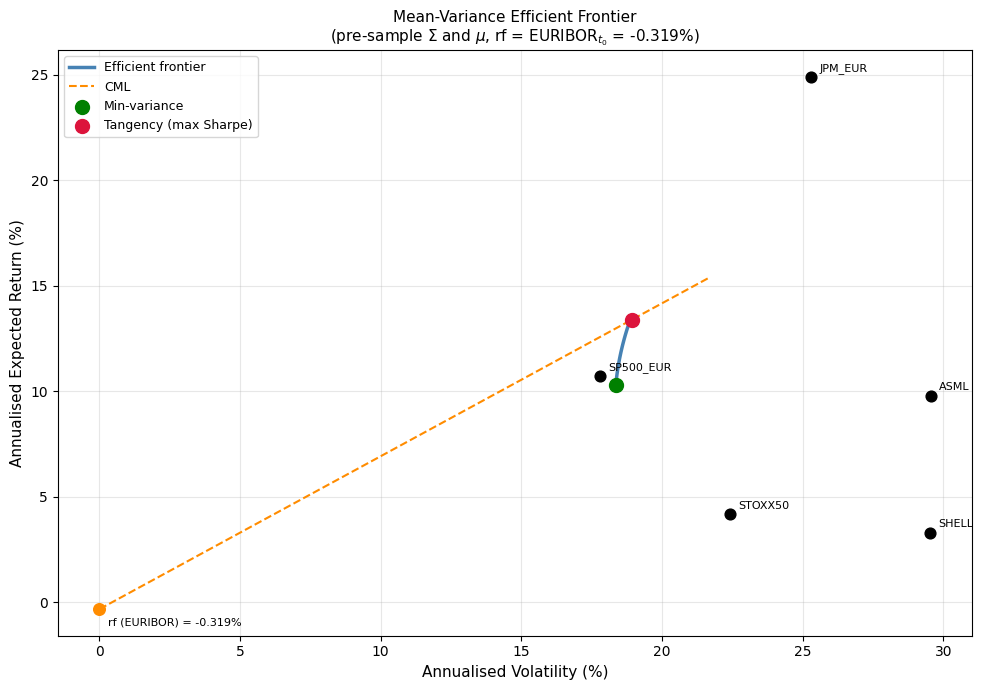

In [109]:
# ── Efficient frontier ────────────────────────────────────────────────────────
targetrets = np.linspace(mu.min() * 0.8, mu.max() * 1.1, 300)
frontiervols, frontierrets = [], []

for target in targetrets:
    res = minimize(
        fun=lambda w: w @ S @ w,
        x0=x0, method="SLSQP", bounds=bounds,
        constraints=[
            {"type": "eq", "fun": lambda w: w.sum() - 1},
            {"type": "eq", "fun": lambda w, t=target: w @ mu - t},
        ],
        options={"ftol": 1e-12, "maxiter": 1000}
    )
    if res.success:
        frontiervols.append(np.sqrt(res.fun))
        frontierrets.append(target)

frontiervols = np.array(frontiervols)
frontierrets = np.array(frontierrets)

# upper (efficient) half only
ret_minvar = w_minvar @ mu
mask    = frontierrets >= ret_minvar
effvols = frontiervols[mask]
effrets = frontierrets[mask]

# CML: from rf through tangency point
vol_tan = np.sqrt(w_tangent @ S @ w_tangent)
ret_tan = w_tangent @ mu
cmlvols = np.linspace(0, effvols.max() * 1.15, 200)
cmlrets = rf + (ret_tan - rf) / vol_tan * cmlvols

# individual asset scatter (pre-sample)
assetvols = np.sqrt(np.diag(S))
assetrets = mu

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(effvols * 100, effrets * 100,
        color="steelblue", linewidth=2.5, label="Efficient frontier")
ax.plot(cmlvols * 100, cmlrets * 100,
        color="darkorange", linewidth=1.5, linestyle="--", label="CML")

ax.scatter(assetvols * 100, assetrets * 100,
           color="black", s=60, zorder=5)
for i, col in enumerate(RISKY):
    ax.annotate(col, (assetvols[i] * 100, assetrets[i] * 100),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.scatter(np.sqrt(w_minvar @ S @ w_minvar) * 100, ret_minvar * 100,
           color="green", s=100, zorder=6, label="Min-variance")

ax.scatter(vol_tan * 100, ret_tan * 100,
           color="crimson", s=100, zorder=6, label="Tangency (max Sharpe)")

ax.scatter(0, rf * 100, color="darkorange", s=70, zorder=6)
ax.annotate(f"rf (EURIBOR) = {rf*100:.3f}%", (0, rf * 100),
            textcoords="offset points", xytext=(6, -12), fontsize=8)

ax.set_xlabel("Annualised Volatility (%)", fontsize=11)
ax.set_ylabel("Annualised Expected Return (%)", fontsize=11)
ax.set_title(
    "Mean-Variance Efficient Frontier\n"
    r"(pre-sample $\Sigma$ and $\mu$, "
    f"rf = EURIBOR$_{{t_0}}$ = {rf*100:.3f}%)",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/efficientfrontier.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Plots

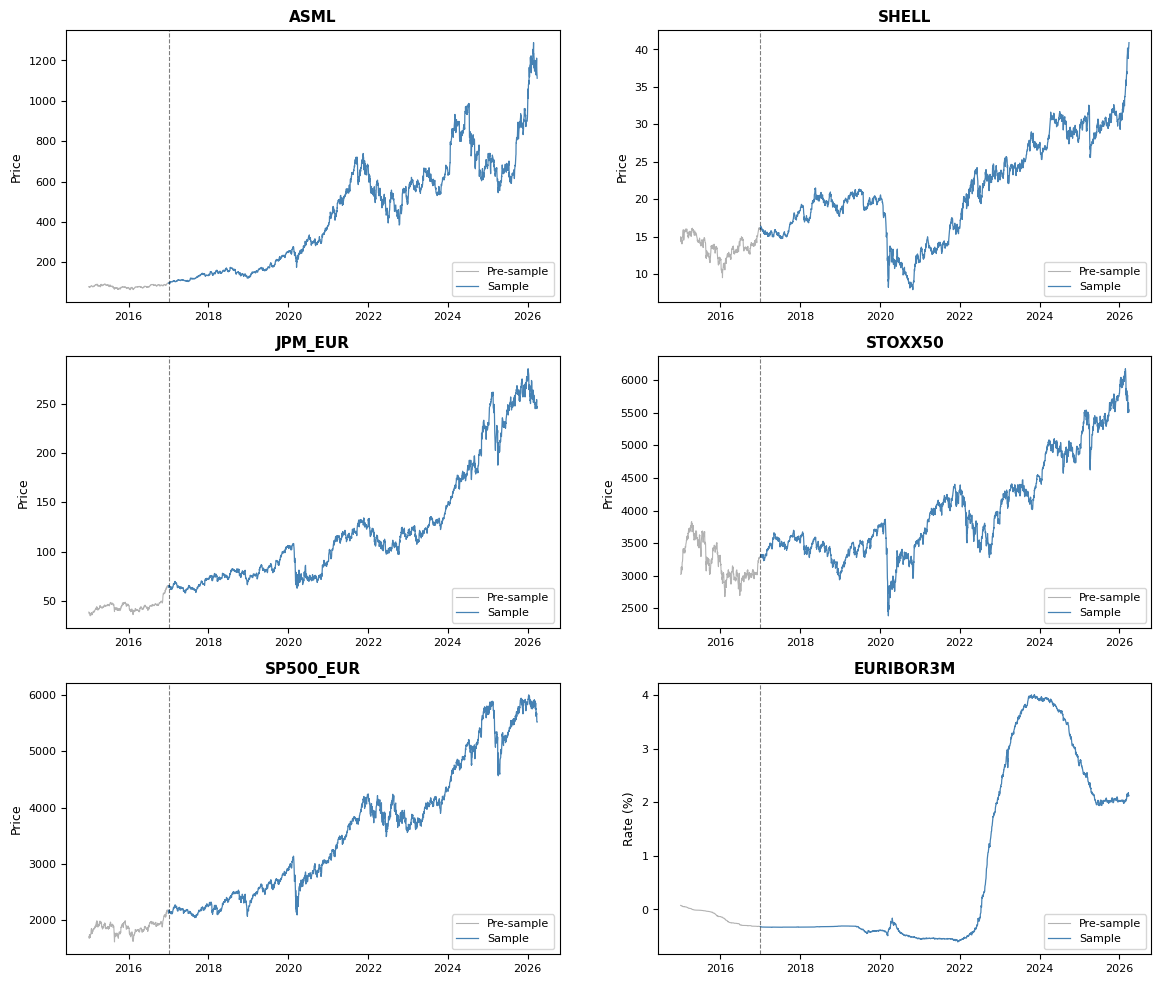

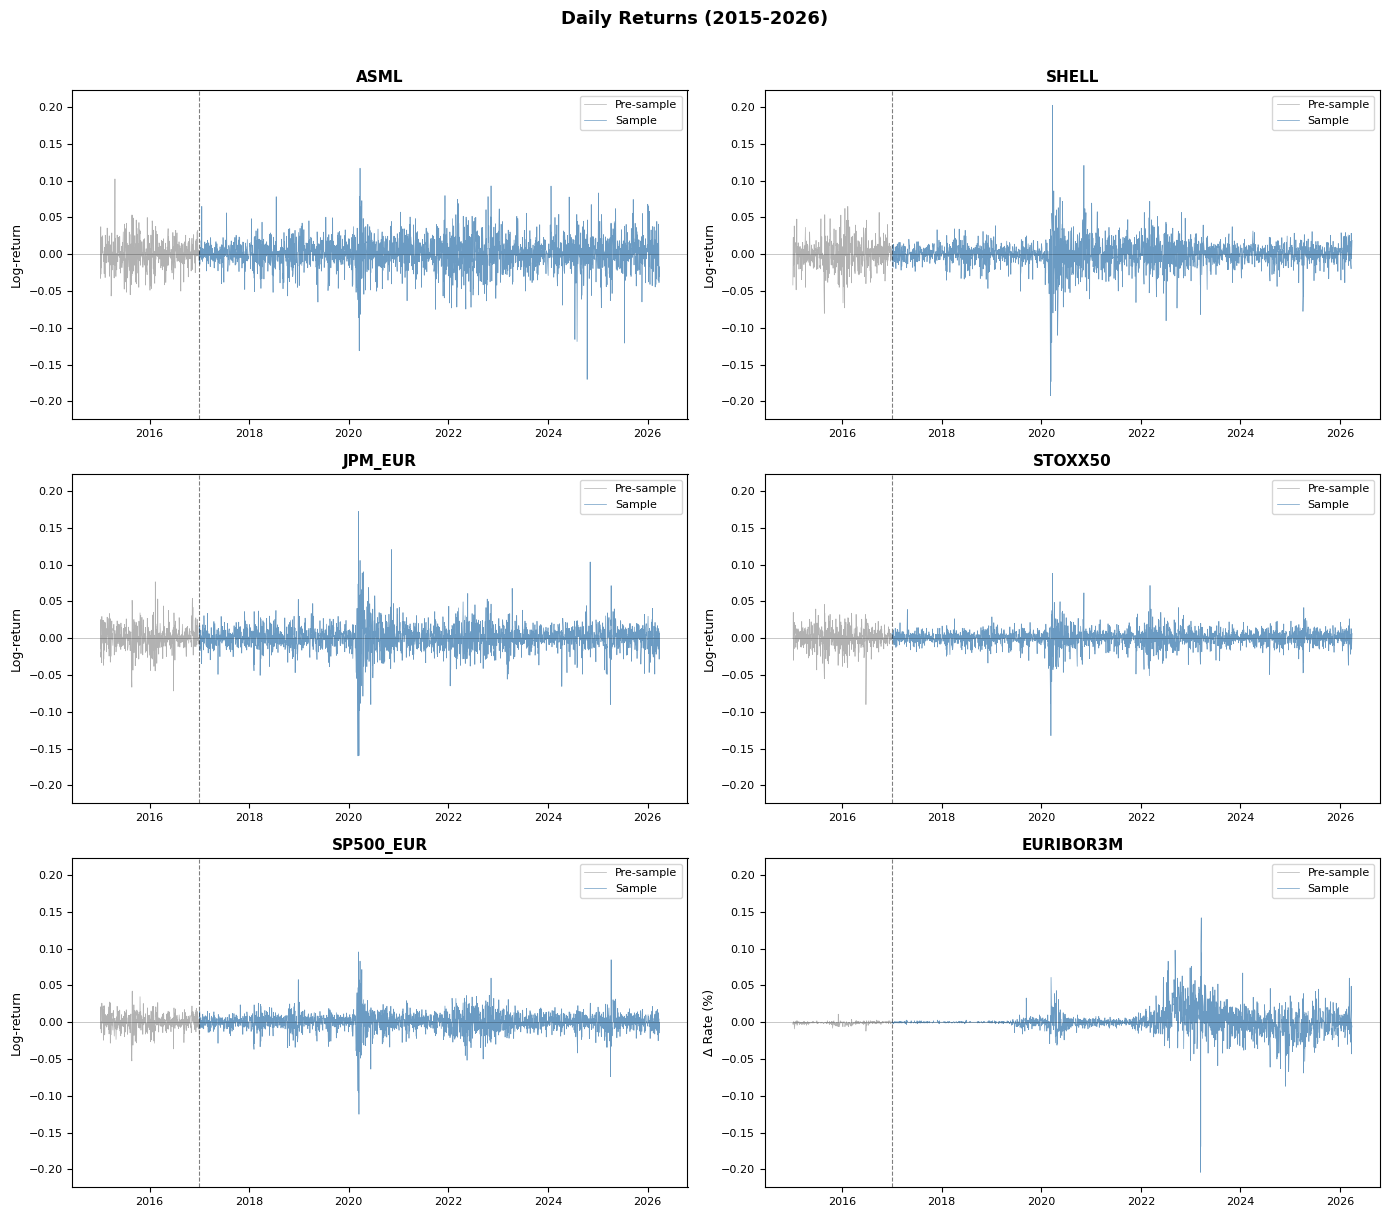

In [110]:
# ── Prices (RISKY + EURIBOR) ──────────────────────────────────────────────────
PLOT_ASSETS = RISKY + RATE   # 6 assets — fills the 3×2 grid exactly

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(PLOT_ASSETS):
    ax = axes[i]
    ax.plot(prices_clean.loc[PRE_START:PRE_END, col],
            color="grey", linewidth=0.8, alpha=0.6, label="Pre-sample")
    ax.plot(prices_clean.loc[SAMPLE_START:SAMPLE_END, col],
            color="steelblue", linewidth=0.9, label="Sample")
    ax.axvline(pd.Timestamp(SAMPLE_START), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Price" if col != "EURIBOR3M" else "Rate (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)

# ── Returns (RISKY + EURIBOR, shared y-axis) ──────────────────────────────────
# compute global y-limits across all assets
all_returns = [returns.loc[PRE_START:SAMPLE_END, col].dropna() for col in PLOT_ASSETS]
global_min  = min(r.min() for r in all_returns)
global_max  = max(r.max() for r in all_returns)
pad         = (global_max - global_min) * 0.05   # 5% padding
ylim        = (global_min - pad, global_max + pad)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(PLOT_ASSETS):
    ax = axes[i]
    ax.plot(returns.loc[PRE_START:PRE_END, col],
            color="grey", linewidth=0.5, alpha=0.6, label="Pre-sample")
    ax.plot(returns.loc[SAMPLE_START:SAMPLE_END, col],
            color="steelblue", linewidth=0.5, alpha=0.8, label="Sample")
    ax.axvline(pd.Timestamp(SAMPLE_START), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.set_ylim(ylim)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Log-return" if col != "EURIBOR3M" else "Δ Rate (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)

plt.suptitle("Daily Returns (2015-2026)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/returns.png", dpi=150, bbox_inches="tight")
plt.show()

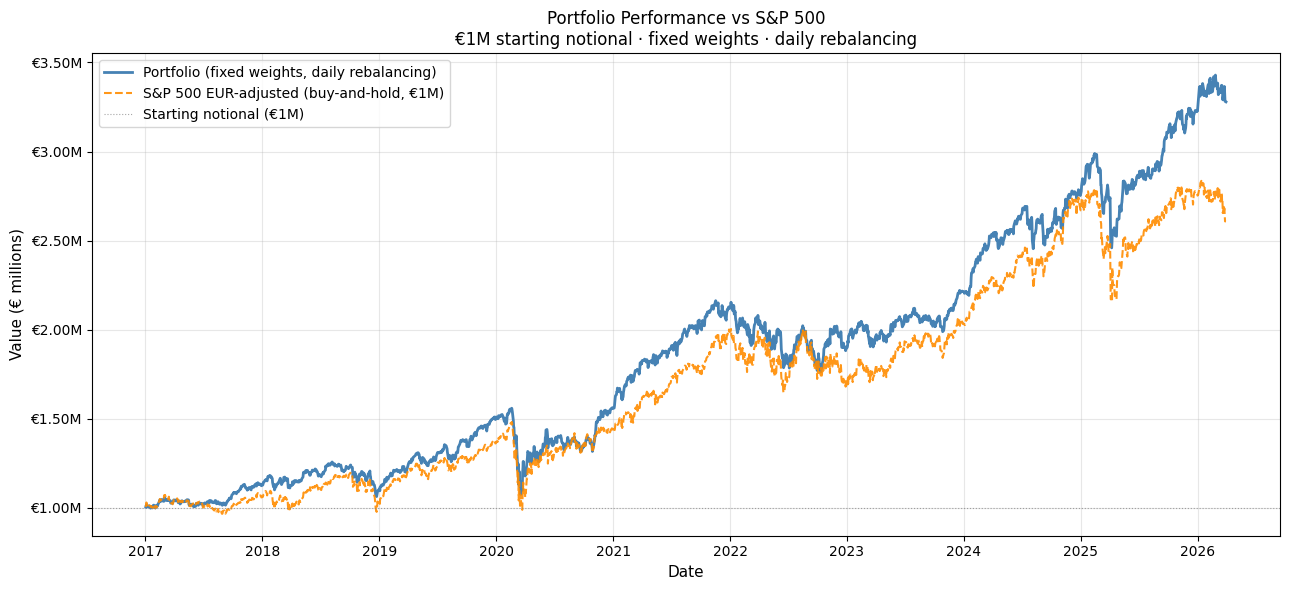

                                   Portfolio   S&P 500 EUR
Final value                        3,278,630     2,607,472
Total return                          227.9%        160.7%
Ann. return (CAGR)                     13.7%         10.9%
Ann. volatility                        15.8%         19.5%
Sharpe ratio                           0.899         0.638


In [111]:
# ── Portfolio Performance Over Time ───────────────────────────────────────────
import matplotlib.dates as mdates

returns_plot = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True)
returns_plot = returns_plot.loc[SAMPLE_START:SAMPLE_END]

# EUR-adjusted returns already in CSV — no manual r_USD − r_EURUSD needed

# ── Rebalanced portfolio (fixed weights, daily) ────────────────────────────────
port_ret   = sum(WEIGHTS[a] * np.expm1(returns_plot[a]) for a in WEIGHTS)
port_value = PORTFOLIO_VALUE * (1 + pd.Series(port_ret, index=returns_plot.index)).cumprod()

# ── S&P 500 standalone EUR-adjusted buy-and-hold (same €1M notional) ──────────
sp500_value = PORTFOLIO_VALUE * (1 + np.expm1(returns_plot["SP500_EUR"])).cumprod()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(port_value.index, port_value / 1e6,
        color="steelblue", linewidth=2.0,
        label="Portfolio (fixed weights, daily rebalancing)")
ax.plot(sp500_value.index, sp500_value / 1e6,
        color="darkorange", linewidth=1.5, linestyle="--", alpha=0.9,
        label="S&P 500 EUR-adjusted (buy-and-hold, €1M)")
ax.axhline(PORTFOLIO_VALUE / 1e6, color="grey", linewidth=0.8,
           linestyle=":", alpha=0.7, label="Starting notional (€1M)")

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Value (€ millions)", fontsize=11)
ax.set_title(
    "Portfolio Performance vs S&P 500\n"
    f"€{PORTFOLIO_VALUE/1e6:.0f}M starting notional · fixed weights · daily rebalancing",
    fontsize=12
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=0)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/portfolio_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
n_years         = (pd.Timestamp(SAMPLE_END) - pd.Timestamp(SAMPLE_START)).days / 365.25
total_ret_port  = (port_value.iloc[-1]  / PORTFOLIO_VALUE - 1) * 100
total_ret_sp500 = (sp500_value.iloc[-1] / PORTFOLIO_VALUE - 1) * 100

port_daily_ret  = pd.Series(port_ret, index=returns_plot.index)
sp500_daily_ret = np.expm1(returns_plot["SP500_EUR"])

rf_daily     = EURIBOR_T0 / 100 / TRADING_DAYS
sharpe_port  = (port_daily_ret.mean()  - rf_daily) / port_daily_ret.std()  * np.sqrt(TRADING_DAYS)
sharpe_sp500 = (sp500_daily_ret.mean() - rf_daily) / sp500_daily_ret.std() * np.sqrt(TRADING_DAYS)

print(f"{'':30s}  {'Portfolio':>12}  {'S&P 500 EUR':>12}")
print(f"{'Final value':30s}  {port_value.iloc[-1]:>12,.0f}  {sp500_value.iloc[-1]:>12,.0f}")
print(f"{'Total return':30s}  {total_ret_port:>11.1f}%  {total_ret_sp500:>11.1f}%")
print(f"{'Ann. return (CAGR)':30s}  "
      f"{((1+total_ret_port/100)**(1/n_years)-1)*100:>11.1f}%  "
      f"{((1+total_ret_sp500/100)**(1/n_years)-1)*100:>11.1f}%")
print(f"{'Ann. volatility':30s}  "
      f"{port_daily_ret.std()  * np.sqrt(TRADING_DAYS) * 100:>11.1f}%  "
      f"{sp500_daily_ret.std() * np.sqrt(TRADING_DAYS) * 100:>11.1f}%")
print(f"{'Sharpe ratio':30s}  {sharpe_port:>12.3f}  {sharpe_sp500:>12.3f}")

---
**Commenting List for Report**
- Choice of tickers
- Time periods and frequencies
- Data Cleaning: dropping and filling
- Portfolio Weight optimisation
- Issue with EURIBOR for 10y loan
